<a href="https://colab.research.google.com/github/vaishnaviikommidi007/FreshBite/blob/main/Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import zipfile

zip_file = "archive (2).zip"   # Corrected ZIP filename

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import os

os.listdir()

['.config',
 'Metro_Interstate_Traffic_Volume.csv',
 'archive (2).zip',
 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [ ]:
df["date_time"] = pd.to_datetime(df["date_time"])

In [ ]:
df["holiday"]=df["holiday"].fillna("No holiday")

In [ ]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [ ]:
df["holiday"].unique()

array(['No holiday', 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [ ]:
df["weather_main"].unique()

array(['Clouds', 'Clear', 'Rain', 'Drizzle', 'Mist', 'Haze', 'Fog',
       'Thunderstorm', 'Snow', 'Squall', 'Smoke'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


In [ ]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711616,3259.818355
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670


In [ ]:
df['clouds_all'].unique()

array([ 40,  75,  90,   1,  20,   0, 100,  92,  99,  81,  50,  72,  56,
        57,  93,  85,  68,  87,  91,  96,  48,  60,   8,  38,  46,  98,
        86,  16,   6,  59,  54,  89,  78,  36,  17,  58,  63,  42,  25,
        11,  13,  83,  70,  84,   3,  77,  88,  67,  97,  62,  32,   4,
         5,   2,  44,  24,  76,  64,  80,  12])

In [ ]:
df.head(6)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,No holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,No holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,No holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,No holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,No holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
5,No holiday,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181


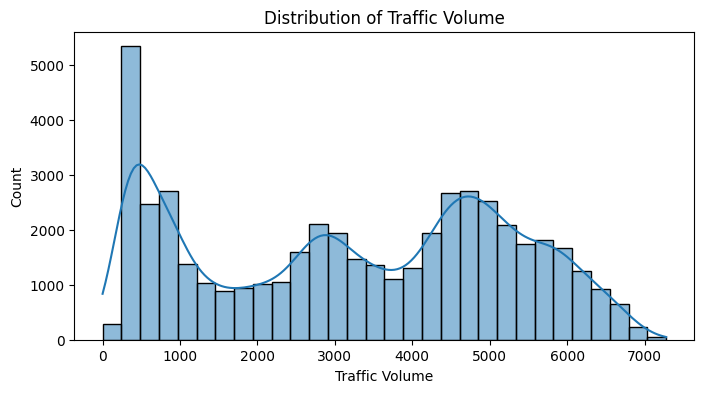

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['traffic_volume'], kde=True, bins=30)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.show()

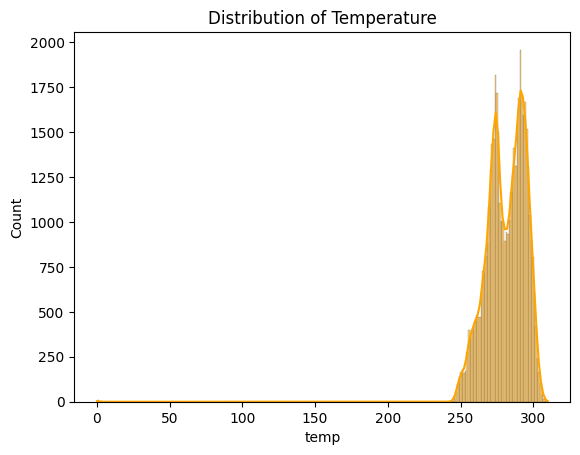

In [ ]:
sns.histplot(df['temp'], kde=True, color='orange')
plt.title('Distribution of Temperature')
plt.show()

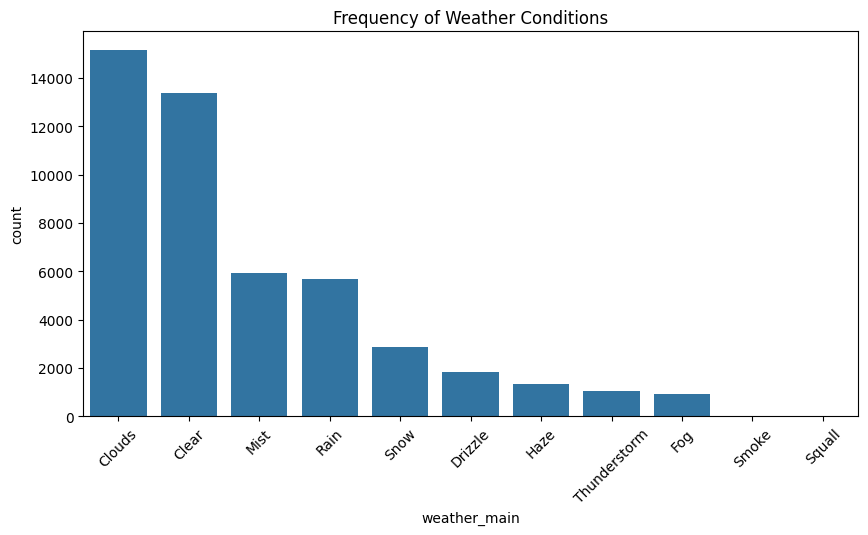

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='weather_main', order=df['weather_main'].value_counts().index)
plt.title('Frequency of Weather Conditions')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df['holiday'].value_counts())

holiday
No holiday                   48143
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
Martin Luther King Jr Day        6
New Years Day                    6
Veterans Day                     5
Columbus Day                     5
Memorial Day                     5
Washingtons Birthday             5
State Fair                       5
Independence Day                 5
Name: count, dtype: int64


In [ ]:
df['hour'] = df['date_time'].dt.hour
df['day_name'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['is_weekend'] = df['date_time'].dt.dayofweek >= 5

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
 9   hour                 48204 non-null  int32         
 10  day_name             48204 non-null  object        
 11  month                48204 non-null  int32         
 12  is_weekend           48204 non-null  bool          
dtypes: bool(1), datetime64[ns](1), 

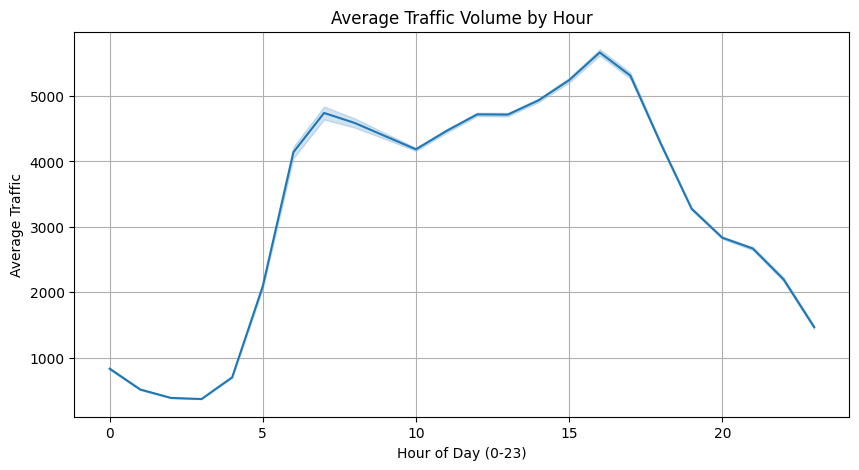

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='traffic_volume', estimator='mean')
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Traffic')
plt.grid(True)
plt.show()

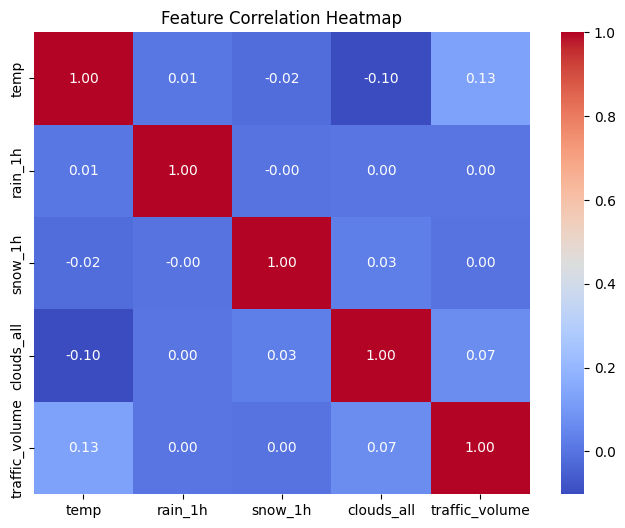

In [ ]:


# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

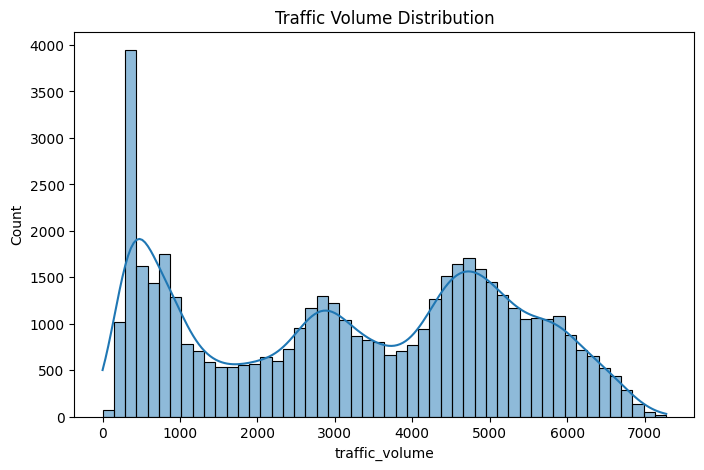

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["traffic_volume"],
    bins=50,
    kde=True
)

plt.title("Traffic Volume Distribution")
plt.show()

In [ ]:
df["hour"] = df["date_time"].dt.hour

In [ ]:
hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

hourly_traffic

,traffic_volume
hour,
0,834.781051
1,516.449000
2,388.353640
3,371.090864
4,702.551889
5,2094.573437
6,4140.503594
7,4740.181337
8,4587.497115


In [ ]:
df.groupby("rain_1h")["traffic_volume"].mean()

,traffic_volume
rain_1h,
0.00,3257.336321
0.25,3261.965190
0.26,5945.500000
0.27,5130.000000
0.28,3736.782609
...,...
28.70,1190.000000
31.75,4913.000000
44.45,4802.000000


In [ ]:
df.head(100)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_name,month,is_weekend
0,No holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,False
1,No holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,False
2,No holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,False
3,No holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,False
4,No holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,No holiday,280.00,0.0,0.0,75,Clouds,broken clouds,2012-10-06 15:00:00,5153,15,Saturday,10,True
96,No holiday,279.06,0.0,0.0,90,Clouds,overcast clouds,2012-10-06 16:00:00,5024,16,Saturday,10,True
97,No holiday,278.91,0.0,0.0,90,Clouds,overcast clouds,2012-10-06 17:00:00,4779,17,Saturday,10,True
98,No holiday,278.39,0.0,0.0,90,Clouds,overcast clouds,2012-10-06 18:00:00,4362,18,Saturday,10,True


In [ ]:
df['rain_1h'].unique()

array([0.0000e+00, 2.5000e-01, 5.7000e-01, 3.8000e-01, 3.0000e-01,
       2.9000e-01, 4.4000e-01, 3.6000e-01, 2.1600e+00, 3.3900e+00,
       8.4000e-01, 7.6000e-01, 5.1000e-01, 6.9000e-01, 1.0000e+00,
       1.2900e+00, 1.3400e+00, 1.8400e+00, 1.7000e+00, 4.7000e-01,
       1.4100e+00, 1.4400e+00, 7.0000e-01, 3.1800e+00, 6.1000e-01,
       6.4000e-01, 1.0200e+00, 5.4200e+00, 8.6400e+00, 5.7400e+00,
       4.9800e+00, 3.6500e+00, 6.8000e-01, 4.6000e-01, 4.2000e-01,
       1.5200e+00, 8.9000e-01, 1.4000e+00, 1.2190e+01, 2.2900e+00,
       7.5400e+00, 6.9400e+00, 1.6380e+01, 1.7800e+00, 2.5400e+00,
       9.1400e+00, 3.0500e+00, 1.6500e+00, 4.4450e+01, 3.8100e+00,
       5.8400e+00, 3.5600e+00, 7.3700e+00, 1.3500e+00, 1.6000e+01,
       1.0540e+01, 1.2700e+00, 5.0800e+00, 1.9900e+01, 2.5320e+01,
       2.1420e+01, 5.5900e+00, 7.1100e+00, 5.9700e+00, 9.5300e+00,
       2.0300e+00, 5.5630e+01, 1.3210e+01, 6.6000e+00, 5.6000e-01,
       3.2000e-01, 2.3700e+00, 3.9800e+00, 4.3200e+00, 1.9600e

<Axes: >

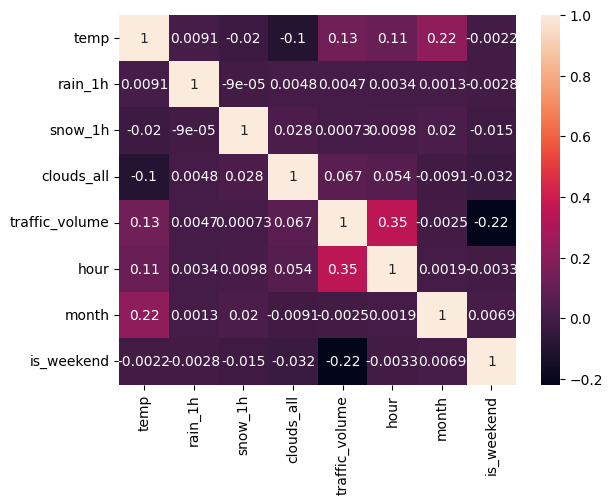

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True
)

In [ ]:
def rush_hour(hour):
    if 6 <= hour <= 9:
        return "Morning Rush"
    elif 15 <= hour <= 17:
        return "Evening Rush"
    else:
        return "Normal"

df["rush_hour"] = df["hour"].apply(rush_hour)

In [ ]:
df.head(10)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_name,month,is_weekend,rush_hour
0,No holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,False,Morning Rush
1,No holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,False,Normal
2,No holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,False,Normal
3,No holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,False,Normal
4,No holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,False,Normal
5,No holiday,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181,14,Tuesday,10,False,Normal
6,No holiday,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,5584,15,Tuesday,10,False,Evening Rush
7,No holiday,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,6015,16,Tuesday,10,False,Evening Rush
8,No holiday,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,5791,17,Tuesday,10,False,Evening Rush
9,No holiday,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,4770,18,Tuesday,10,False,Normal


In [ ]:
corr = df.corr()

sns.heatmap(
    corr,
    annot=True
)

ValueError: could not convert string to float: 'Clouds'

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

le = LabelEncoder()

df_corr["holiday"] = le.fit_transform(df_corr["holiday"])
df_corr["weather_main"] = le.fit_transform(df_corr["weather_main"])
df_corr["weather_description"] = le.fit_transform(df_corr["weather_description"])
df_corr["rush_hour"] = le.fit_transform(df_corr["rush_hour"])

In [ ]:
corr = df_corr.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

ValueError: could not convert string to float: 'Tuesday'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()


NameError: name 'corr_matrix' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_name,month,is_weekend,rush_hour
0,No holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,False,Morning Rush
1,No holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,False,Normal
2,No holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,False,Normal
3,No holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,False,Normal
4,No holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,False,Normal
